In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### functions

In [1]:

# ============================================================
# Generic helpers
# ============================================================

def compute_fuel_share(df: pd.DataFrame,
                       fuel_col: str,
                       fuel_name: str,
                       value_col: str = "Value",
                       year_col: str = "Year") -> pd.DataFrame:
    """Compute annual share (%) of a given fuel in total generation.

    Returns
    -------
    DataFrame with columns:
        Year, Total_GWh, <fuel_name>_GWh, <fuel_name>_pct
    """
    wide = df.pivot(index=year_col, columns=fuel_col, values=value_col)
    wide["Total_GWh"] = wide.sum(axis=1)
    wide[f"{fuel_name}_GWh"] = wide[fuel_name]
    wide[f"{fuel_name}_pct"] = wide[fuel_name] / wide["Total_GWh"] * 100.0
    out = wide[["Total_GWh", f"{fuel_name}_GWh", f"{fuel_name}_pct"]].reset_index()
    out.rename(columns={year_col: "Year"}, inplace=True)
    return out


def fit_linear_trend(years: np.ndarray, values: np.ndarray, t0: int = None):
    """Fit linear trend v(t) = a + b*(t - t0).

    Returns
    -------
    (a, b, t0)
    """
    if t0 is None:
        t0 = int(years.min())
    x = years - t0
    A = np.vstack([x, np.ones_like(x)]).T
    b_slope, a_intercept = np.linalg.lstsq(A, values, rcond=None)[0]
    return float(a_intercept), float(b_slope), t0


def linear_path(v0, v1, t0, t1, years):
    """Linear interpolation / extrapolation between (t0, v0) and (t1, v1)."""
    years = np.asarray(years)
    return v0 + (v1 - v0) * (years - t0) / (t1 - t0)


def build_ssp_shares(years_historical,
                     shares_historical,
                     anchor_year,
                     ssp1_2050,
                     ssp2_2050,
                     ssp5_2050,
                     last_year=2050):
    """From a historical share series, build SSP1/SSP2/SSP5 share paths (%)."""
    hist_df = pd.DataFrame({"Year": years_historical, "Share_pct": shares_historical})
    anchor_share = float(hist_df.loc[hist_df["Year"] == anchor_year, "Share_pct"])
    future_years = np.arange(anchor_year, last_year + 1)
    ssp_defs = {
        "SSP1-RCP1.9": ssp1_2050,
        "SSP2-RCP4.5": ssp2_2050,
        "SSP5-RCP8.5": ssp5_2050,
    }
    scenarios = {}
    for ssp_name, target_2050 in ssp_defs.items():
        fut_shares = linear_path(anchor_share, target_2050,
                                 anchor_year, last_year, future_years)
        df_ssp = pd.DataFrame({"Year": future_years, "Share_pct": fut_shares})
        scenarios[ssp_name] = df_ssp
    return hist_df, scenarios


def plot_ssp_shares(hist_df, scenarios, title, ylabel, ylim=None):
    """Plot historical + SSP futures for a single marker fuel."""
    plt.figure()
    plt.plot(hist_df["Year"], hist_df["Share_pct"], "k-", label="Historical")
    for name, df_s in scenarios.items():
        plt.plot(df_s["Year"], df_s["Share_pct"], label=name)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def scenario_snapshot_table(scenarios, years=(2030, 2040, 2050)):
    """Extract a table of scenario shares (%) at selected years."""
    rows = []
    for name, df_s in scenarios.items():
        row = {"Scenario": name}
        for y in years:
            val = float(df_s.loc[df_s["Year"] == y, "Share_pct"])
            row[str(y)] = round(val, 1)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Scenario")



### plot, and final %

In [8]:

china_path = "../IEA_CA_CN/International Energy Agency - electricity generation in China.csv"    
canada_path = "../IEA_CA_CN/International Energy Agency - electricity generation in Canada.csv"   


/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_11755/2124384464.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  cp_2023 = float(coal_share_ch.loc[coal_share_ch["Year"] == 2023, "Coal_pct"])
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_11755/1545779448.py:60: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  anchor_share = float(hist_df.loc[hist_df["Year"] == anchor_year, "Share_pct"])


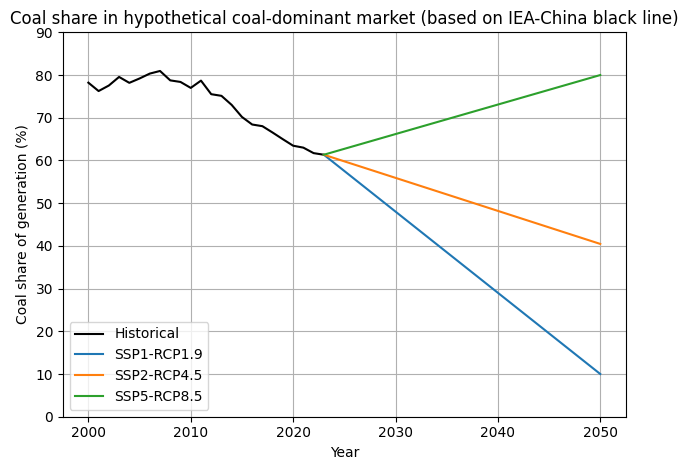

In [6]:
 
df_china = pd.read_csv(china_path)

coal_share_ch = compute_fuel_share(
    df_china,
    fuel_col="electricity generation in China",
    fuel_name="Coal",
    value_col="Value",
    year_col="Year",
)

years_ch = coal_share_ch["Year"].to_numpy()
coal_pct_hist = coal_share_ch["Coal_pct"].to_numpy()

# linear trend for historic endpoint
a_coal, b_coal, t0_coal = fit_linear_trend(years_ch, coal_pct_hist)
coal_2050_lin = a_coal + b_coal * (2050 - t0_coal)

cp_2023 = float(coal_share_ch.loc[coal_share_ch["Year"] == 2023, "Coal_pct"])

# assumption for 2050 coal share (%)
ssp1_coal_2050 = 10.0          # strong mitigation
ssp2_coal_2050 = coal_2050_lin # BAU, continue historical linear trend, 
ssp5_coal_2050 = 80.0          # fossil-fuelled

hist_coal_df, coal_scenarios = build_ssp_shares(
    years_ch,
    coal_pct_hist,
    anchor_year=2023,
    ssp1_2050=ssp1_coal_2050,
    ssp2_2050=ssp2_coal_2050,
    ssp5_2050=ssp5_coal_2050,
    last_year=2050,
)

plot_ssp_shares(
    hist_coal_df,
    coal_scenarios,
    title="Coal share in hypothetical coal-dominant market (based on IEA-China black line)",
    ylabel="Coal share of generation (%)",
    ylim=(0, 90),
)


In [7]:

coal_snapshot = scenario_snapshot_table(coal_scenarios)
coal_snapshot


/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_11755/1545779448.py:99: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  val = float(df_s.loc[df_s["Year"] == y, "Share_pct"])


,2030,2040,2050
Scenario,,,
SSP1-RCP1.9,48.0,29.0,10.0
SSP2-RCP4.5,55.9,48.2,40.5
SSP5-RCP8.5,66.2,73.1,80.0


/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_11755/3314822876.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  hp_2024 = float(hydro_share_ca.loc[hydro_share_ca["Year"] == 2024, "Hydropower_pct"])
/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_11755/1545779448.py:60: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  anchor_share = float(hist_df.loc[hist_df["Year"] == anchor_year, "Share_pct"])


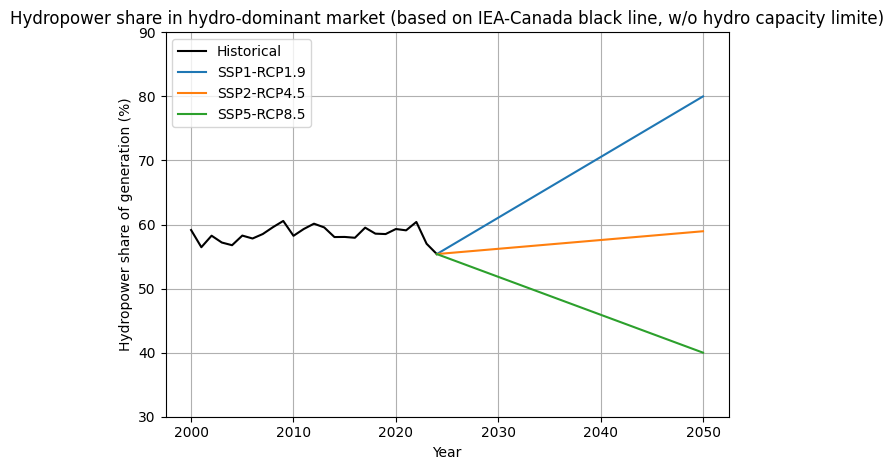

In [14]:

df_can = pd.read_csv(canada_path)

hydro_share_ca = compute_fuel_share(
    df_can,
    fuel_col="electricity generation in Canada",
    fuel_name="Hydropower",
    value_col="Value",
    year_col="Year",
)

years_ca = hydro_share_ca["Year"].to_numpy()
hydro_pct_hist = hydro_share_ca["Hydropower_pct"].to_numpy()

a_hydro, b_hydro, t0_hydro = fit_linear_trend(years_ca, hydro_pct_hist)
hydro_2050_lin = a_hydro + b_hydro * (2050 - t0_hydro)

hp_2024 = float(hydro_share_ca.loc[hydro_share_ca["Year"] == 2024, "Hydropower_pct"])


# assumptions for 2050 hydro share (%)
ssp1_hydro_2050 = 80.0           # sustainability: hydro remains dominant
ssp2_hydro_2050 = hydro_2050_lin # middle-of-road: similar level 
ssp5_hydro_2050 = 40.0           # fossil-fuelled: hydro share erodes

hist_hydro_df, hydro_scenarios = build_ssp_shares(
    years_ca,
    hydro_pct_hist,
    anchor_year=2024,
    ssp1_2050=ssp1_hydro_2050,
    ssp2_2050=ssp2_hydro_2050,
    ssp5_2050=ssp5_hydro_2050,
    last_year=2050,
)

plot_ssp_shares(
    hist_hydro_df,
    hydro_scenarios,
    title="Hydropower share in hydro-dominant market (based on IEA-Canada black line, w/o hydro capacity limite)",
    ylabel="Hydropower share of generation (%)",
    ylim=(30, 90),
)



In [15]:
hydro_snapshot = scenario_snapshot_table(hydro_scenarios)
hydro_snapshot

/var/folders/9p/gvkl7h6551515cs56m93ldgr0000gn/T/ipykernel_11755/1545779448.py:99: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  val = float(df_s.loc[df_s["Year"] == y, "Share_pct"])


,2030,2040,2050
Scenario,,,
SSP1-RCP1.9,61.1,70.5,80.0
SSP2-RCP4.5,56.2,57.6,59.0
SSP5-RCP8.5,51.8,45.9,40.0
